Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9314 - loss: 0.2235 - val_accuracy: 0.9797 - val_loss: 0.0681
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.9792 - loss: 0.0697 - val_accuracy: 0.9876 - val_loss: 0.0450
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - accuracy: 0.9837 - loss: 0.0512 - val_accuracy: 0.9889 - val_loss: 0.0425
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.9870 - loss: 0.0401 - val_accuracy: 0.9889 - val_loss: 0.0380
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.9900 - loss: 0.0319 - val_accuracy: 0.9888 - val_loss: 0.0395
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9909 - loss: 0.0315
Test Accuracy: 0.9908999800682068
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


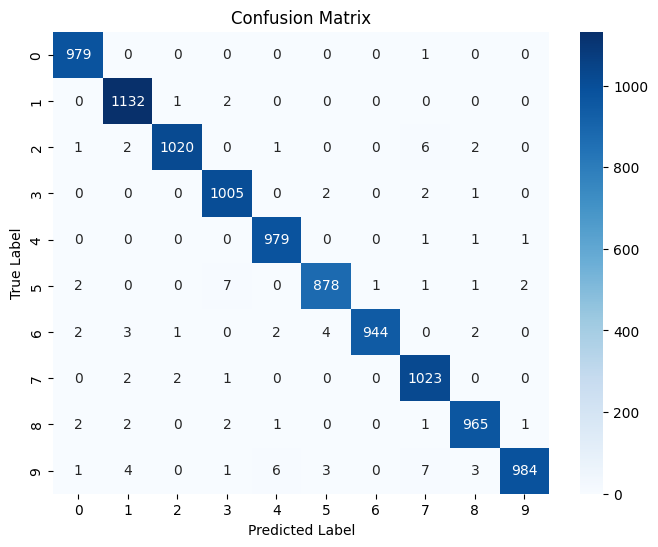

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", test_accuracy)

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_classes))